**Equipe:**
- Matheus Virgolino Abilio da Silva - 124210975
- Jefferson Ribeiro Brasil - 123110470
- João Gabriel Eulálio Luiggi Ramos - 121110737
- José Vitor Barbosa Maciel - 120210954
- Pedro Wilson Silva de Sousa - 124211096

# Pré-processamento de dados

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/meteorological_data.csv')

# Basic info
info = df.info()
nulls = df.isnull().sum()
head = df.head()

print("Columns and Nulls:")
print(nulls)
print("\nFirst 5 rows:")
print(head)

#Com base nisso, vamos fazer o préprocessamento dos dados

#convert timestamp para datetime

df['Timestamp (UTC)'] = pd.to_datetime(df['Timestamp (UTC)'])
df.set_index('Timestamp (UTC)', inplace=True)

# Fill Radiation NaNs with 0 (assuming night time)
df['Radiation (KJ/m²)'] = df['Radiation (KJ/m²)'].fillna(0)

# Interpolate other missing values linearly
df = df.interpolate(method='time')

# Forward fill or backward fill any remaining NaNs at the edges
df = df.bfill().ffill()

# Save preprocessed data
df.to_csv('../data/preprocessed_meteorological_data.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Timestamp (UTC)      744 non-null    object 
 1   Temp. Ins. (C)       708 non-null    float64
 2   Temp. Max. (C)       707 non-null    float64
 3   Temp. Min. (C)       707 non-null    float64
 4   Pressure Ins. (hPa)  709 non-null    float64
 5   Pressure Max. (hPa)  708 non-null    float64
 6   Pressure Min. (hPa)  708 non-null    float64
 7   Wind Speed (m/s)     709 non-null    float64
 8   Wind Dir. (m/s)      709 non-null    float64
 9   Wind Gust (m/s)      708 non-null    float64
 10  Radiation (KJ/m²)    371 non-null    float64
 11  Rain (mm)            708 non-null    float64
dtypes: float64(11), object(1)
memory usage: 69.9+ KB
Columns and Nulls:
Timestamp (UTC)          0
Temp. Ins. (C)          36
Temp. Max. (C)          37
Temp. Min. (C)          37
Pressure Ins. 

# Análise Exploratória de dados(EDA)

In [17]:
sns.set_theme(style="whitegrid")

# Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Climáticas')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.close()

# Distributions (Histograms)
cols_to_plot = ['Temp. Ins. (C)', 'Pressure Ins. (hPa)', 'Wind Speed (m/s)', 'Radiation (KJ/m²)', 'Rain (mm)']
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribuição de {col}')

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('distributions.png')
plt.close()

# Summary statistics
summary_stats = df.describe()
print(summary_stats)

       Temp. Ins. (C)  Temp. Max. (C)  Temp. Min. (C)  Pressure Ins. (hPa)  \
count      744.000000      744.000000      744.000000           744.000000   
mean        26.265659       26.744489       25.793011          1012.674059   
std          2.714359        2.878405        2.539338             2.714164   
min         20.700000       20.800000       20.700000          1005.800000   
25%         24.300000       24.700000       23.975000          1010.900000   
50%         25.950000       26.300000       25.500000          1012.400000   
75%         27.900000       28.500000       27.200000          1014.700000   
max         34.500000       35.400000       34.000000          1020.000000   

       Pressure Max. (hPa)  Pressure Min. (hPa)  Wind Speed (m/s)  \
count           744.000000           744.000000        744.000000   
mean           1012.892272          1012.432527          1.344489   
std               2.692404             2.715003          0.908000   
min            1006.2

/tmp/ipykernel_94183/3831707551.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df_cleaned['Temp. Ins. (C)'], df_cleaned['Temp. Max. (C)'], df_cleaned['Temp. Min. (C)']],


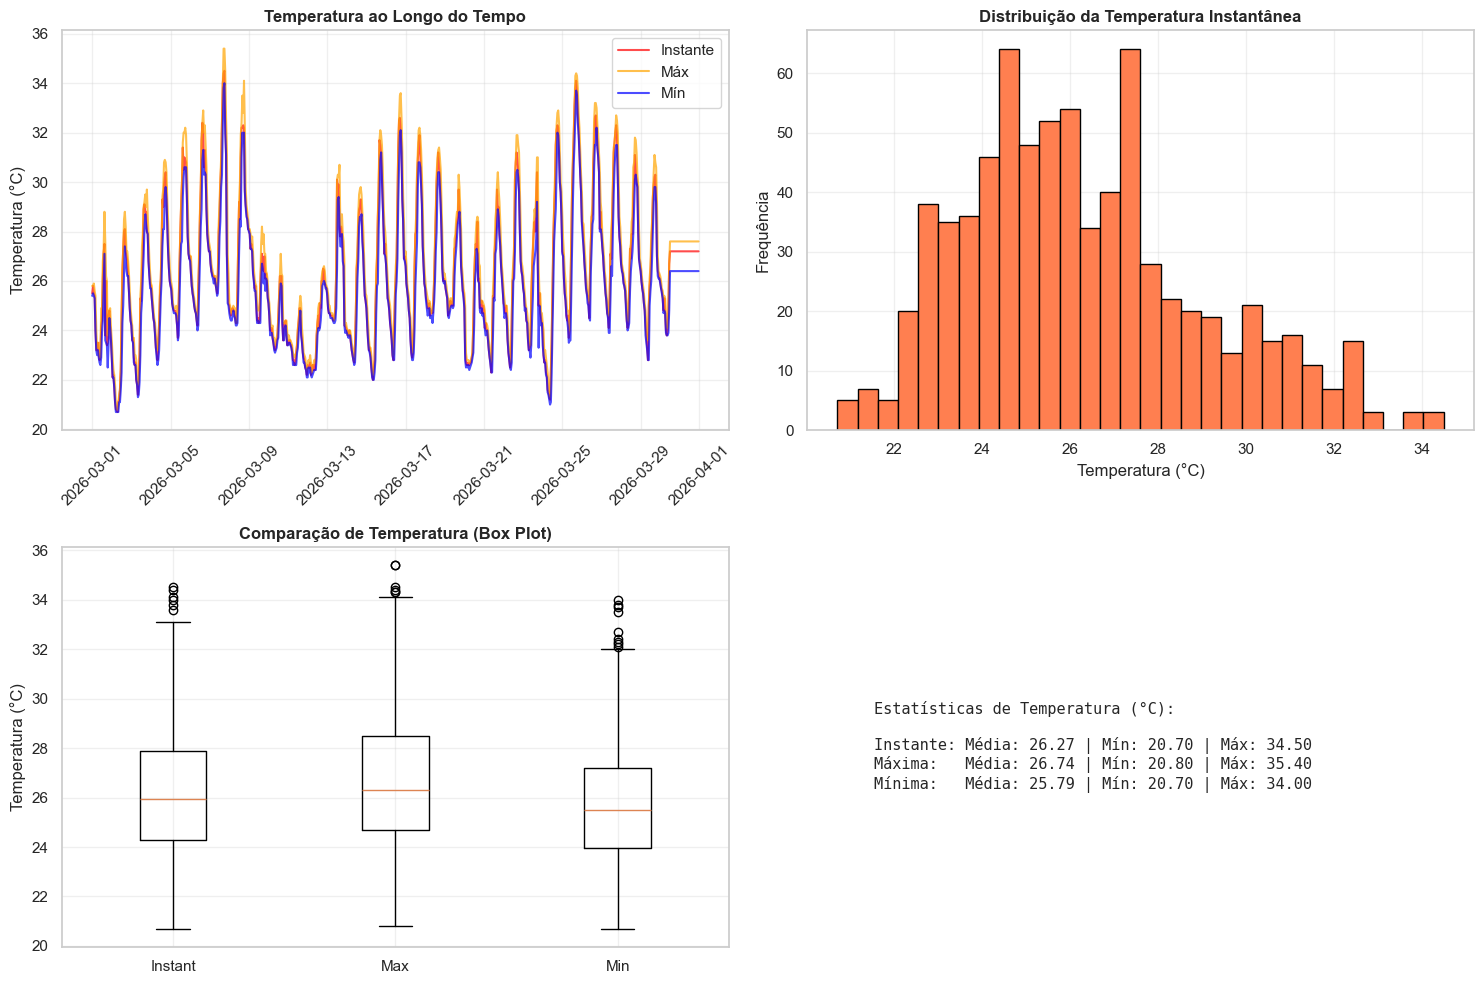

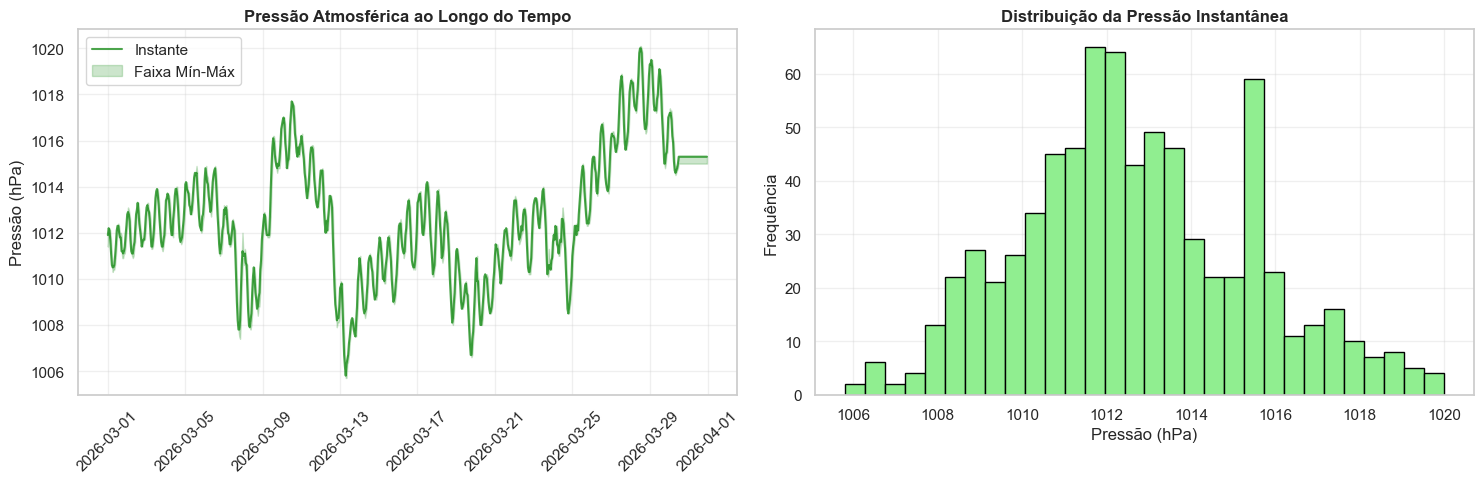

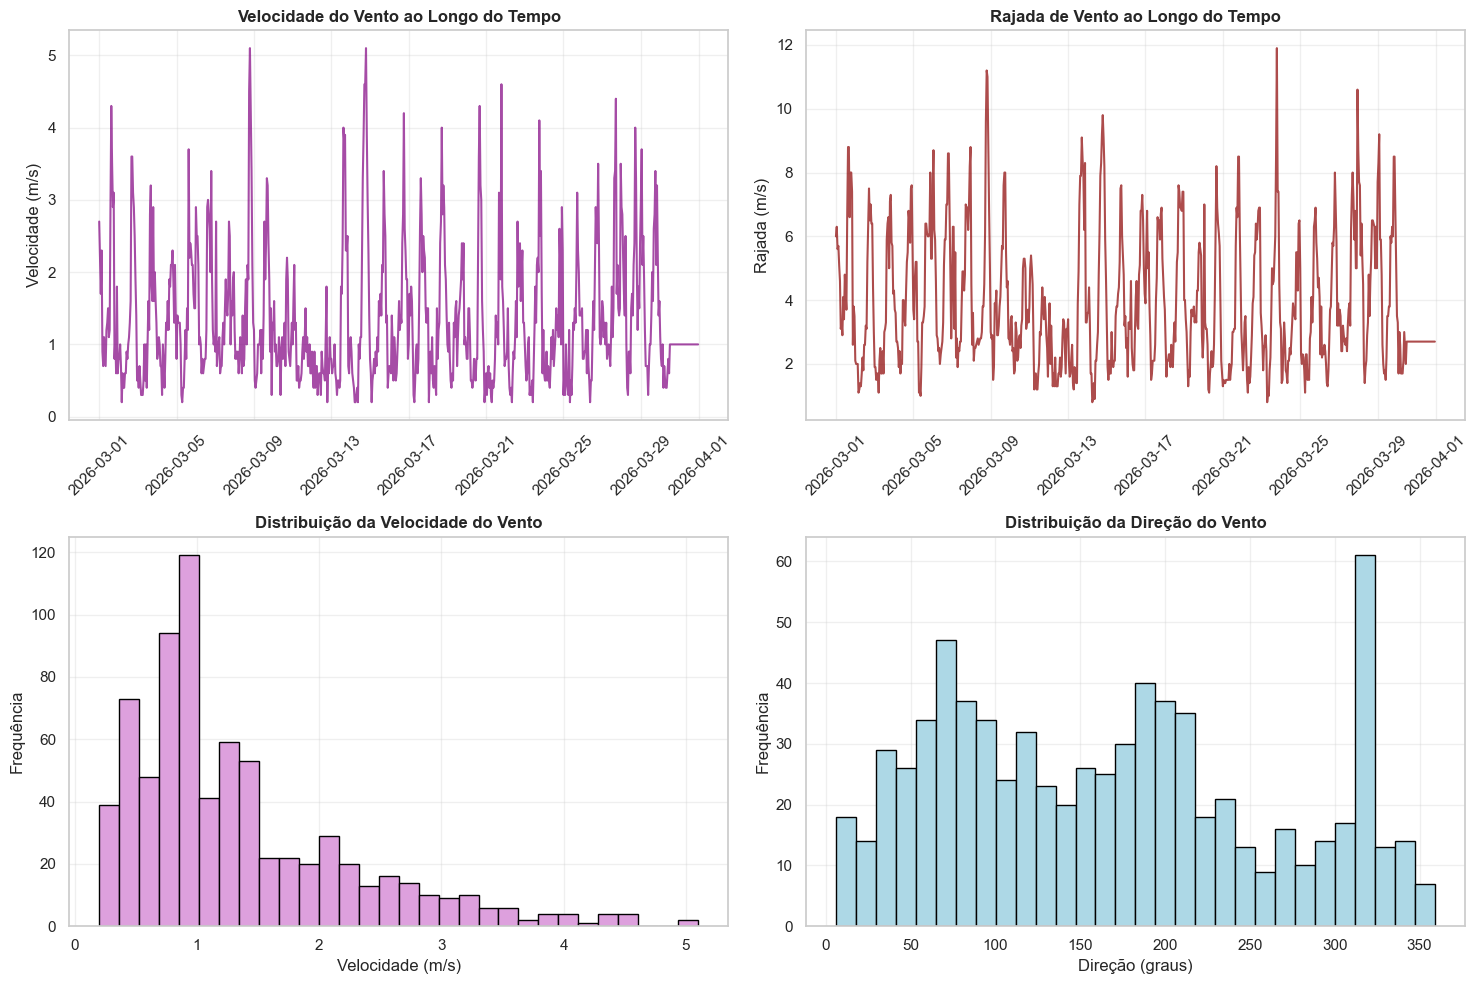

In [18]:
#Complementando a análise com o exemplo no repositório do netmob

import pandas as pd
import matplotlib.pyplot as plt

# Carrega os dados pré-processados, definindo a coluna de data como índice temporal
df_cleaned = pd.read_csv('../data/preprocessed_meteorological_data.csv', index_col='Timestamp (UTC)', parse_dates=True)

# ==========================================
# 1. Análise de Temperatura
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Variações de Temperatura
axes[0, 0].plot(df_cleaned.index, df_cleaned['Temp. Ins. (C)'], label='Instante', color='red', alpha=0.7)
axes[0, 0].plot(df_cleaned.index, df_cleaned['Temp. Max. (C)'], label='Máx', color='orange', alpha=0.7)
axes[0, 0].plot(df_cleaned.index, df_cleaned['Temp. Min. (C)'], label='Mín', color='blue', alpha=0.7)
axes[0, 0].set_title('Temperatura ao Longo do Tempo', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Temperatura (°C)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Histograma de Temperatura
axes[0, 1].hist(df_cleaned['Temp. Ins. (C)'], bins=30, color='coral', edgecolor='black')
axes[0, 1].set_title('Distribuição da Temperatura Instantânea', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Temperatura (°C)')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].grid(True, alpha=0.3)

# Box plot de Temperatura
axes[1, 0].boxplot([df_cleaned['Temp. Ins. (C)'], df_cleaned['Temp. Max. (C)'], df_cleaned['Temp. Min. (C)']], 
                   labels=['Instant', 'Max', 'Min'])
axes[1, 0].set_title('Comparação de Temperatura (Box Plot)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Temperatura (°C)')
axes[1, 0].grid(True, alpha=0.3)

# Estatísticas de Temperatura
axes[1, 1].axis('off')
temp_stats = f"""Estatísticas de Temperatura (°C):

Instante: Média: {df_cleaned['Temp. Ins. (C)'].mean():.2f} | Mín: {df_cleaned['Temp. Ins. (C)'].min():.2f} | Máx: {df_cleaned['Temp. Ins. (C)'].max():.2f}
Máxima:   Média: {df_cleaned['Temp. Max. (C)'].mean():.2f} | Mín: {df_cleaned['Temp. Max. (C)'].min():.2f} | Máx: {df_cleaned['Temp. Max. (C)'].max():.2f}
Mínima:   Média: {df_cleaned['Temp. Min. (C)'].mean():.2f} | Mín: {df_cleaned['Temp. Min. (C)'].min():.2f} | Máx: {df_cleaned['Temp. Min. (C)'].max():.2f}"""
axes[1, 1].text(0.1, 0.5, temp_stats, fontsize=11, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

# ==========================================
# 2. Análise de Pressão
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Variações de Pressão
axes[0].plot(df_cleaned.index, df_cleaned['Pressure Ins. (hPa)'], label='Instante', color='green', alpha=0.7, linewidth=1.5)
axes[0].fill_between(df_cleaned.index, df_cleaned['Pressure Min. (hPa)'], df_cleaned['Pressure Max. (hPa)'], 
                     alpha=0.2, color='green', label='Faixa Mín-Máx')
axes[0].set_title('Pressão Atmosférica ao Longo do Tempo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pressão (hPa)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Histograma de Pressão
axes[1].hist(df_cleaned['Pressure Ins. (hPa)'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribuição da Pressão Instantânea', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pressão (hPa)')
axes[1].set_ylabel('Frequência')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 3. Análise de Vento
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Variações de Velocidade do Vento
axes[0, 0].plot(df_cleaned.index, df_cleaned['Wind Speed (m/s)'], color='purple', alpha=0.7, linewidth=1.5)
axes[0, 0].set_title('Velocidade do Vento ao Longo do Tempo', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Velocidade (m/s)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Variações de Rajada de Vento
axes[0, 1].plot(df_cleaned.index, df_cleaned['Wind Gust (m/s)'], color='darkred', alpha=0.7, linewidth=1.5)
axes[0, 1].set_title('Rajada de Vento ao Longo do Tempo', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Rajada (m/s)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Histograma de Velocidade
axes[1, 0].hist(df_cleaned['Wind Speed (m/s)'], bins=30, color='plum', edgecolor='black')
axes[1, 0].set_title('Distribuição da Velocidade do Vento', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Velocidade (m/s)')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].grid(True, alpha=0.3)

# Histograma de Direção
axes[1, 1].hist(df_cleaned['Wind Dir. (m/s)'], bins=30, color='lightblue', edgecolor='black')
axes[1, 1].set_title('Distribuição da Direção do Vento', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Direção (graus)')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()